# Home task: data engineering

# ETL Pipeline with PostgreSQL

This notebook builds a local ETL pipeline for e-commerce CSV data.

Stack:

- Python
- pandas
- PostgreSQL
- Docker Compose

## Import libraries


In [8]:
from pathlib import Path
import logging
import re

import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text

## Paths and database connection


In [9]:
BASE_DIR = Path(".")
DATA_DIR = BASE_DIR / "data"

RAW_FILES = {
    "customers": DATA_DIR / "customers.csv",
    "orders": DATA_DIR / "orders.csv",
    "order_items": DATA_DIR / "order_items.csv",
    "products": DATA_DIR / "products.csv",
}

DB_USER = "postgres"
DB_PASSWORD = "postgres"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "shop_db"

DATABASE_URL = f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(DATABASE_URL)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)

logger = logging.getLogger(__name__)

## Read raw data


In [10]:
def read_csv_files(file_paths):
    dataframes = {}

    for table_name, file_path in file_paths.items():
        if not file_path.exists():
            raise FileNotFoundError(f"Missing file: {file_path}")

        df = pd.read_csv(file_path)
        dataframes[table_name] = df

        logger.info("%s loaded: %s rows", table_name, df.shape[0])

    return dataframes


raw_data = read_csv_files(RAW_FILES)

for name, df in raw_data.items():
    print(f"\n{name}")
    display(df.head())

2026-05-04 23:36:30,772 | INFO | customers loaded: 357 rows
2026-05-04 23:36:30,779 | INFO | orders loaded: 456 rows
2026-05-04 23:36:30,785 | INFO | order_items loaded: 914 rows
2026-05-04 23:36:30,790 | INFO | products loaded: 155 rows



customers


,customer_id,email,country,created_at
0,1.0,user1@example.com,DE,2024-01-04 23:17:00
1,2.0,user2@example.com,PL,2024-01-29 04:47:00
2,3.0,user3@example.com,DE,2024-03-27 23:57:00
3,4.0,user4@example.com,CZ,2024-01-12 18:27:00
4,5.0,user5@example.com,US,2024-01-04 02:13:00



orders


,order_id,customer_id,order_status,created_at
0,5001,307.0,completed,2024-05-09 06:49:00
1,5002,71.0,completed,2024-04-16 00:31:00
2,5003,221.0,completed,2024-06-08 22:14:00
3,5004,257.0,pending,2024-07-13 11:04:00
4,5005,204.0,completed,2024-04-03 14:58:00



order_items


,order_item_id,order_id,product_id,quantity
0,1,5001,1142,5
1,2,5001,1068,3
2,3,5002,1061,1
3,4,5002,1013,4
4,5,5003,1141,4



products


,product_id,name,category,price
0,1001,Toys Product 1001,Toys,810.03
1,1002,Stationery Product 1002,Stationery,797.22
2,1003,Stationery Product 1003,Stationery,1246.05
3,1004,Stationery Product 1004,Stationery,1371.25
4,1005,Books Product 1005,Books,1451.14


## Check raw data quality


In [11]:
EMAIL_PATTERN = re.compile(r"^[^@\s]+@[^@\s]+\.[^@\s]+$")


def add_check(report, table, check, count):
    report.append({
        "table_name": table,
        "check_name": check,
        "issue_count": int(count)
    })


def check_raw_quality(data):
    report = []

    customers = data["customers"]
    products = data["products"]
    orders = data["orders"]
    order_items = data["order_items"]

    add_check(report, "customers", "missing_customer_id", customers["customer_id"].isna().sum())
    add_check(report, "customers", "duplicate_customer_id", customers["customer_id"].duplicated(keep=False).sum())
    add_check(report, "customers", "missing_email", customers["email"].isna().sum())
    add_check(report, "customers", "invalid_email", (~customers["email"].fillna("").str.match(EMAIL_PATTERN)).sum())
    add_check(report, "customers", "invalid_created_at", pd.to_datetime(customers["created_at"], errors="coerce").isna().sum())

    add_check(report, "products", "duplicate_product_id", products["product_id"].duplicated(keep=False).sum())
    add_check(report, "products", "missing_name", products["name"].isna().sum())
    add_check(report, "products", "missing_category", products["category"].isna().sum())
    add_check(report, "products", "invalid_price", (products["price"] <= 0).sum())

    valid_statuses = {"completed", "pending", "cancelled"}
    statuses = orders["order_status"].astype(str).str.lower().str.strip()

    add_check(report, "orders", "duplicate_order_id", orders["order_id"].duplicated(keep=False).sum())
    add_check(report, "orders", "missing_customer_id", orders["customer_id"].isna().sum())
    add_check(report, "orders", "invalid_created_at", pd.to_datetime(orders["created_at"], errors="coerce").isna().sum())
    add_check(report, "orders", "unknown_status", (~statuses.isin(valid_statuses)).sum())

    add_check(report, "order_items", "duplicate_order_item_id", order_items["order_item_id"].duplicated(keep=False).sum())
    add_check(report, "order_items", "invalid_quantity", (order_items["quantity"] <= 0).sum())

    return pd.DataFrame(report)


raw_quality_report = check_raw_quality(raw_data)
display(raw_quality_report)

,table_name,check_name,issue_count
0,customers,missing_customer_id,1
1,customers,duplicate_customer_id,6
2,customers,missing_email,2
3,customers,invalid_email,4
4,customers,invalid_created_at,1
5,products,duplicate_product_id,2
6,products,missing_name,1
7,products,missing_category,1
8,products,invalid_price,2
9,orders,duplicate_order_id,2


## Clean data


In [12]:
def clean_customers(customers):
    df = customers.copy()

    df["customer_id"] = pd.to_numeric(df["customer_id"], errors="coerce")
    df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")
    df["email"] = df["email"].astype("string").str.lower().str.strip()
    df["country"] = df["country"].astype("string").str.upper().str.strip()

    # customer must have valid id, email, and date
    df = df.dropna(subset=["customer_id", "email", "created_at"])
    df = df[df["email"].str.match(EMAIL_PATTERN, na=False)]

    df["customer_id"] = df["customer_id"].astype(int)
    df = df.drop_duplicates(subset=["customer_id"], keep="first")

    return df.reset_index(drop=True)


def clean_products(products):
    df = products.copy()

    df["product_id"] = pd.to_numeric(df["product_id"], errors="coerce")
    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df["name"] = df["name"].astype("string").str.strip()
    df["category"] = df["category"].astype("string").str.strip()

    # price must be positive for sales analysis
    df = df.dropna(subset=["product_id", "name", "category", "price"])
    df = df[df["price"] > 0]

    df["product_id"] = df["product_id"].astype(int)
    df = df.drop_duplicates(subset=["product_id"], keep="first")

    return df.reset_index(drop=True)


def clean_orders(orders, customers):
    df = orders.copy()

    valid_statuses = {"completed", "pending", "cancelled"}
    valid_customer_ids = set(customers["customer_id"])

    df["order_id"] = pd.to_numeric(df["order_id"], errors="coerce")
    df["customer_id"] = pd.to_numeric(df["customer_id"], errors="coerce")
    df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")
    df["order_status"] = df["order_status"].astype("string").str.lower().str.strip()

    df = df.dropna(subset=["order_id", "customer_id", "created_at", "order_status"])

    df["order_id"] = df["order_id"].astype(int)
    df["customer_id"] = df["customer_id"].astype(int)

    # order must have known status and existing customer
    df = df[df["order_status"].isin(valid_statuses)]
    df = df[df["customer_id"].isin(valid_customer_ids)]
    df = df.drop_duplicates(subset=["order_id"], keep="first")

    return df.reset_index(drop=True)


def clean_order_items(order_items, orders, products):
    df = order_items.copy()

    valid_order_ids = set(orders["order_id"])
    valid_product_ids = set(products["product_id"])

    df["order_item_id"] = pd.to_numeric(df["order_item_id"], errors="coerce")
    df["order_id"] = pd.to_numeric(df["order_id"], errors="coerce")
    df["product_id"] = pd.to_numeric(df["product_id"], errors="coerce")
    df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")

    df = df.dropna(subset=["order_item_id", "order_id", "product_id", "quantity"])

    df["order_item_id"] = df["order_item_id"].astype(int)
    df["order_id"] = df["order_id"].astype(int)
    df["product_id"] = df["product_id"].astype(int)
    df["quantity"] = df["quantity"].astype(int)

    # keep only rows linked to real orders and products
    df = df[df["quantity"] > 0]
    df = df[df["order_id"].isin(valid_order_ids)]
    df = df[df["product_id"].isin(valid_product_ids)]
    df = df.drop_duplicates(subset=["order_item_id"], keep="first")

    return df.reset_index(drop=True)

## Run cleaning step


In [13]:
cleaned_customers = clean_customers(raw_data["customers"])
cleaned_products = clean_products(raw_data["products"])
cleaned_orders = clean_orders(raw_data["orders"], cleaned_customers)
cleaned_order_items = clean_order_items(raw_data["order_items"], cleaned_orders, cleaned_products)

cleaned_data = {
    "cleaned_customers": cleaned_customers,
    "cleaned_products": cleaned_products,
    "cleaned_orders": cleaned_orders,
    "cleaned_order_items": cleaned_order_items,
}

for name, df in cleaned_data.items():
    print(f"{name}: {df.shape[0]} rows")
    display(df.head())

cleaned_customers: 350 rows


,customer_id,email,country,created_at
0,1,user1@example.com,DE,2024-01-04 23:17:00
1,2,user2@example.com,PL,2024-01-29 04:47:00
2,3,user3@example.com,DE,2024-03-27 23:57:00
3,4,user4@example.com,CZ,2024-01-12 18:27:00
4,5,user5@example.com,US,2024-01-04 02:13:00


cleaned_products: 150 rows


,product_id,name,category,price
0,1001,Toys Product 1001,Toys,810.03
1,1002,Stationery Product 1002,Stationery,797.22
2,1003,Stationery Product 1003,Stationery,1246.05
3,1004,Stationery Product 1004,Stationery,1371.25
4,1005,Books Product 1005,Books,1451.14


cleaned_orders: 451 rows


,order_id,customer_id,order_status,created_at
0,5001,307,completed,2024-05-09 06:49:00
1,5002,71,completed,2024-04-16 00:31:00
2,5003,221,completed,2024-06-08 22:14:00
3,5004,257,pending,2024-07-13 11:04:00
4,5005,204,completed,2024-04-03 14:58:00


cleaned_order_items: 906 rows


,order_item_id,order_id,product_id,quantity
0,1,5001,1142,5
1,2,5001,1068,3
2,3,5002,1061,1
3,4,5002,1013,4
4,5,5003,1141,4


## Load cleaned data to PostgreSQL

In [14]:
def test_database_connection(engine):
    with engine.connect() as connection:
        result = connection.execute(text("SELECT version();"))
        print(result.fetchone()[0])


test_database_connection(engine)

PostgreSQL 16.13 (Debian 16.13-1.pgdg13+1) on x86_64-pc-linux-gnu, compiled by gcc (Debian 14.2.0-19) 14.2.0, 64-bit


## Load cleaned tables


In [15]:
def load_to_postgres(tables, engine):
    with engine.begin() as connection:
        for table_name, df in tables.items():
            df.to_sql(
                table_name,
                connection,
                if_exists="replace",
                index=False,
                method="multi"
            )

            logger.info("%s saved", table_name)


load_to_postgres(cleaned_data, engine)

2026-05-04 23:36:31,243 | INFO | cleaned_customers saved
2026-05-04 23:36:31,339 | INFO | cleaned_products saved
2026-05-04 23:36:31,463 | INFO | cleaned_orders saved
2026-05-04 23:36:31,614 | INFO | cleaned_order_items saved


## Create analytical tables


In [16]:
def create_analytics_tables(engine, quality_report):
    with engine.begin() as connection:
        quality_report.to_sql(
            "mart_data_quality",
            connection,
            if_exists="replace",
            index=False,
            method="multi"
        )

        connection.execute(text("""
        DROP TABLE IF EXISTS mart_daily_sales;

        CREATE TABLE mart_daily_sales AS
        SELECT
            DATE(o.created_at) AS order_date,
            COUNT(DISTINCT o.order_id) AS orders_count,
            SUM(oi.quantity) AS items_sold,
            ROUND(SUM(oi.quantity * p.price)::numeric, 2) AS revenue
        FROM cleaned_orders o
        JOIN cleaned_order_items oi
            ON o.order_id = oi.order_id
        JOIN cleaned_products p
            ON oi.product_id = p.product_id
        WHERE o.order_status = 'completed'
        GROUP BY DATE(o.created_at)
        ORDER BY order_date;
        """))

        connection.execute(text("""
        DROP TABLE IF EXISTS mart_customer_revenue;

        CREATE TABLE mart_customer_revenue AS
        SELECT
            c.customer_id,
            c.email,
            c.country,
            COUNT(DISTINCT o.order_id) AS completed_orders,
            ROUND(SUM(oi.quantity * p.price)::numeric, 2) AS total_revenue
        FROM cleaned_customers c
        JOIN cleaned_orders o
            ON c.customer_id = o.customer_id
        JOIN cleaned_order_items oi
            ON o.order_id = oi.order_id
        JOIN cleaned_products p
            ON oi.product_id = p.product_id
        WHERE o.order_status = 'completed'
        GROUP BY
            c.customer_id,
            c.email,
            c.country
        ORDER BY total_revenue DESC;
        """))

        connection.execute(text("""
        DROP TABLE IF EXISTS mart_product_sales;

        CREATE TABLE mart_product_sales AS
        SELECT
            p.product_id,
            p.name,
            p.category,
            SUM(oi.quantity) AS units_sold,
            ROUND(SUM(oi.quantity * p.price)::numeric, 2) AS total_revenue
        FROM cleaned_products p
        JOIN cleaned_order_items oi
            ON p.product_id = oi.product_id
        JOIN cleaned_orders o
            ON oi.order_id = o.order_id
        WHERE o.order_status = 'completed'
        GROUP BY
            p.product_id,
            p.name,
            p.category
        ORDER BY total_revenue DESC;
        """))

        connection.execute(text("""
        DROP TABLE IF EXISTS mart_category_sales;

        CREATE TABLE mart_category_sales AS
        SELECT
            p.category,
            COUNT(DISTINCT o.order_id) AS orders_count,
            SUM(oi.quantity) AS units_sold,
            ROUND(SUM(oi.quantity * p.price)::numeric, 2) AS total_revenue
        FROM cleaned_products p
        JOIN cleaned_order_items oi
            ON p.product_id = oi.product_id
        JOIN cleaned_orders o
            ON oi.order_id = o.order_id
        WHERE o.order_status = 'completed'
        GROUP BY p.category
        ORDER BY total_revenue DESC;
        """))


create_analytics_tables(engine, raw_quality_report)

## Check output tables


In [17]:
def read_sql_table(table_name, engine, limit=10):
    query = f"SELECT * FROM {table_name} LIMIT {limit};"
    return pd.read_sql_query(query, engine)


output_tables = [
    "mart_daily_sales",
    "mart_customer_revenue",
    "mart_product_sales",
    "mart_category_sales",
    "mart_data_quality"
]

for table in output_tables:
    print(f"\n{table}")
    display(read_sql_table(table, engine))


mart_daily_sales


,order_date,orders_count,items_sold,revenue
0,2024-04-01,1,6.0,2405.37
1,2024-04-02,2,7.0,3198.22
2,2024-04-03,1,2.0,2413.48
3,2024-04-04,2,8.0,2918.04
4,2024-04-05,1,7.0,6943.04
5,2024-04-06,4,26.0,15875.77
6,2024-04-07,3,25.0,15680.28
7,2024-04-08,3,17.0,12149.60
8,2024-04-09,2,15.0,9938.90
9,2024-04-10,2,13.0,6626.67



mart_customer_revenue


,customer_id,email,country,completed_orders,total_revenue
0,335,user335@example.com,UA,5,22803.45
1,204,user204@example.com,ES,4,21745.49
2,111,user111@example.com,US,2,20527.57
3,323,user323@example.com,ES,3,20349.01
4,89,user89@example.com,CZ,4,20332.38
5,114,user114@example.com,NL,3,20170.28
6,10,user10@example.com,UA,2,19777.37
7,71,user71@example.com,US,3,18465.23
8,6,user6@example.com,PL,2,17543.76
9,44,user44@example.com,UA,2,16490.93



mart_product_sales


,product_id,name,category,units_sold,total_revenue
0,1122,Toys Product 1122,Toys,31.0,38068.00
1,1039,Books Product 1039,Books,22.0,30991.40
2,1047,Electronics Product 1047,Electronics,20.0,28472.40
3,1008,Books Product 1008,Books,17.0,24554.97
4,1142,Books Product 1142,Books,22.0,21858.76
5,1147,Stationery Product 1147,Stationery,21.0,21377.37
6,1140,Toys Product 1140,Toys,23.0,21332.96
7,1009,Furniture Product 1009,Furniture,18.0,20370.96
8,1079,Books Product 1079,Books,15.0,19068.75
9,1036,Beauty Product 1036,Beauty,17.0,18537.65



mart_category_sales


,category,orders_count,units_sold,total_revenue
0,Books,111,390.0,295983.00
1,Toys,100,345.0,241740.06
2,Stationery,88,281.0,194615.45
3,Furniture,70,245.0,174489.95
4,Beauty,91,277.0,167413.31
5,Sports,96,313.0,141730.08
6,Electronics,57,178.0,101521.01



mart_data_quality


,table_name,check_name,issue_count
0,customers,missing_customer_id,1
1,customers,duplicate_customer_id,6
2,customers,missing_email,2
3,customers,invalid_email,4
4,customers,invalid_created_at,1
5,products,duplicate_product_id,2
6,products,missing_name,1
7,products,missing_category,1
8,products,invalid_price,2
9,orders,duplicate_order_id,2


## Daily revenue chart

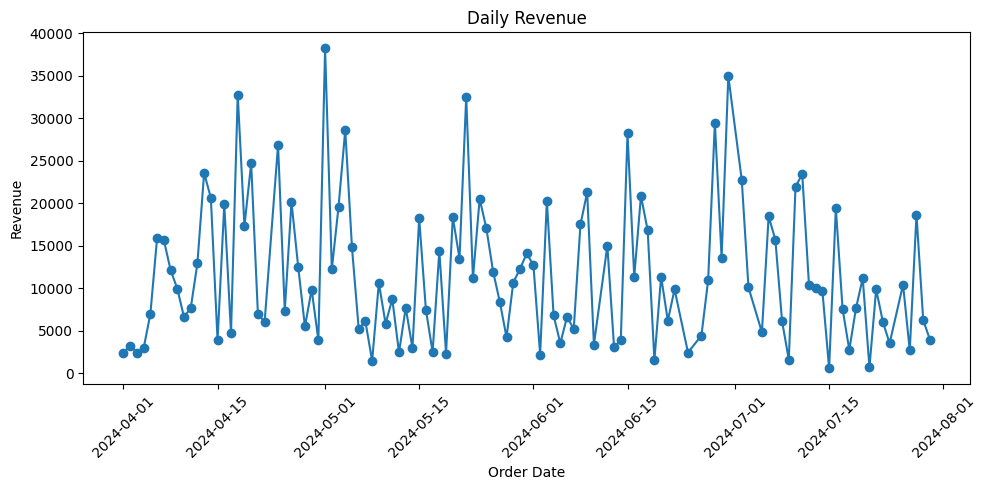

In [18]:
daily_sales = read_sql_table("mart_daily_sales", engine, limit=1000)

plt.figure(figsize=(10, 5))
plt.plot(daily_sales["order_date"], daily_sales["revenue"], marker="o")
plt.title("Daily Revenue")
plt.xlabel("Order Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Revenue by category chart

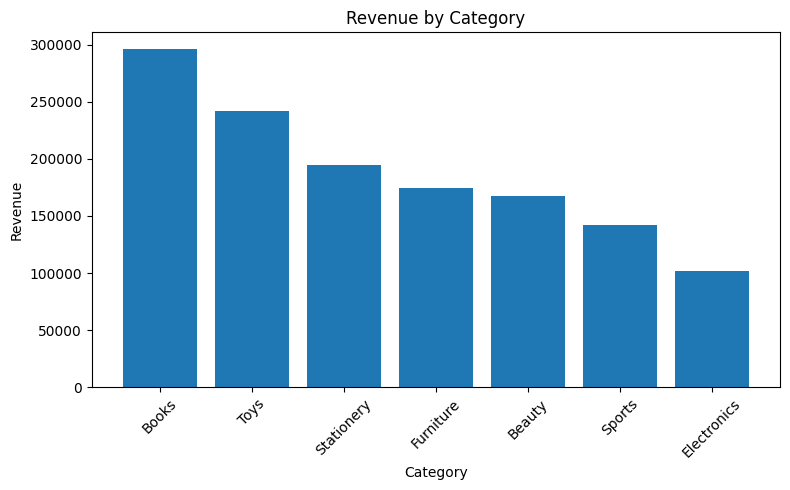

In [19]:
category_sales = read_sql_table("mart_category_sales", engine, limit=1000)

plt.figure(figsize=(8, 5))
plt.bar(category_sales["category"], category_sales["total_revenue"])
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Data quality issues chart


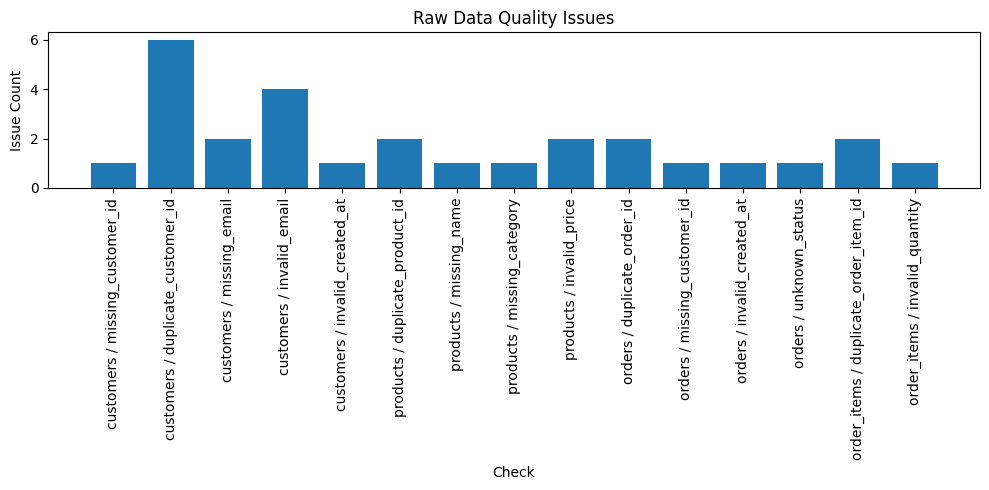

In [20]:
quality = read_sql_table("mart_data_quality", engine, limit=1000)
quality = quality[quality["issue_count"] > 0]

plt.figure(figsize=(10, 5))
plt.bar(
    quality["table_name"] + " / " + quality["check_name"],
    quality["issue_count"]
)
plt.title("Raw Data Quality Issues")
plt.xlabel("Check")
plt.ylabel("Issue Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Cleaning summary

- rows without primary keys were removed because they cannot be identified
- duplicate primary keys were removed because one ID should describe one record
- invalid emails were removed because they are not reliable customer data
- invalid dates were removed because they cannot be used in time-based analysis
- products with price `<= 0` were removed because they break revenue calculation
- unknown order statuses were removed because they do not fit the selected business logic
- order items with quantity `<= 0` were removed because they are not valid sales
- broken foreign key references were removed to keep relations between tables correct


## Output tables

Cleaned tables:

- `cleaned_customers`
- `cleaned_products`
- `cleaned_orders`
- `cleaned_order_items`

Analytical tables:

- `mart_daily_sales` — daily revenue and sold items
- `mart_customer_revenue` — revenue by customer
- `mart_product_sales` — revenue and units sold by product
- `mart_category_sales` — revenue and units sold by category
- `mart_data_quality` — raw data quality checks

## Conclusion

This work implements a local ETL pipeline for e-commerce data

Python and pandas were used to read and clean CSV files
PostgreSQL was used to store cleaned data and analytical tables. 
Docker Compose was used to run PostgreSQL locally

The pipeline is reproducible and can be started on a clean environment in a short time by installing the required packages and running Docker Compose

## Optional task: pytest

As an optional part, I added pytest tests for the cleaned data and analytical tables

The tests check:

- if all expected tables exist
- if primary keys are not missing and not duplicated
- if prices are positive
- if quantities are positive
- if order statuses are valid
- if foreign key references are correct


In [21]:
!pytest tests/test_data_quality.py -q

..........                                                               [100%]
10 passed in 1.09s


## Optional task: SQLite

As another optional part, I saved the cleaned tables into a local SQLite database.



In [22]:
import sqlite3

SQLITE_DB_PATH = BASE_DIR / "shop_analytics_sqlite.db"

## Load data to SQLite

In [23]:
def load_to_sqlite(tables, db_path):
    with sqlite3.connect(db_path) as connection:
        for table_name, df in tables.items():
            df.to_sql(
                table_name,
                connection,
                if_exists="replace",
                index=False
            )

            logger.info("%s saved to SQLite", table_name)


load_to_sqlite(cleaned_data, SQLITE_DB_PATH)

2026-05-04 23:36:34,916 | INFO | cleaned_customers saved to SQLite
2026-05-04 23:36:34,932 | INFO | cleaned_products saved to SQLite
2026-05-04 23:36:34,947 | INFO | cleaned_orders saved to SQLite
2026-05-04 23:36:34,947 | INFO | cleaned_order_items saved to SQLite


## Check SQLite output

In [24]:
def read_sqlite_table(table_name, db_path, limit=10):
    with sqlite3.connect(db_path) as connection:
        query = f"SELECT * FROM {table_name} LIMIT {limit};"
        return pd.read_sql_query(query, connection)


for table in cleaned_data.keys():
    print(f"\n{table}")
    display(read_sqlite_table(table, SQLITE_DB_PATH))


cleaned_customers


,customer_id,email,country,created_at
0,1,user1@example.com,DE,2024-01-04 23:17:00
1,2,user2@example.com,PL,2024-01-29 04:47:00
2,3,user3@example.com,DE,2024-03-27 23:57:00
3,4,user4@example.com,CZ,2024-01-12 18:27:00
4,5,user5@example.com,US,2024-01-04 02:13:00
5,6,user6@example.com,PL,2024-03-05 19:01:00
6,7,user7@example.com,CZ,2024-01-26 22:41:00
7,8,user8@example.com,CZ,2024-02-23 07:28:00
8,9,user9@example.com,SE,2024-02-05 00:48:00
9,10,user10@example.com,UA,2024-03-30 13:21:00



cleaned_products


,product_id,name,category,price
0,1001,Toys Product 1001,Toys,810.03
1,1002,Stationery Product 1002,Stationery,797.22
2,1003,Stationery Product 1003,Stationery,1246.05
3,1004,Stationery Product 1004,Stationery,1371.25
4,1005,Books Product 1005,Books,1451.14
5,1006,Stationery Product 1006,Stationery,1120.35
6,1007,Stationery Product 1007,Stationery,1206.74
7,1008,Books Product 1008,Books,1444.41
8,1009,Furniture Product 1009,Furniture,1131.72
9,1010,Furniture Product 1010,Furniture,1290.49



cleaned_orders


,order_id,customer_id,order_status,created_at
0,5001,307,completed,2024-05-09 06:49:00
1,5002,71,completed,2024-04-16 00:31:00
2,5003,221,completed,2024-06-08 22:14:00
3,5004,257,pending,2024-07-13 11:04:00
4,5005,204,completed,2024-04-03 14:58:00
5,5006,40,cancelled,2024-06-13 12:45:00
6,5007,328,completed,2024-05-22 00:20:00
7,5008,88,completed,2024-06-28 11:05:00
8,5009,224,completed,2024-06-15 12:33:00
9,5010,41,cancelled,2024-07-05 10:14:00



cleaned_order_items


,order_item_id,order_id,product_id,quantity
0,1,5001,1142,5
1,2,5001,1068,3
2,3,5002,1061,1
3,4,5002,1013,4
4,5,5003,1141,4
5,6,5003,1040,1
6,7,5003,1093,1
7,8,5004,1023,3
8,9,5004,1123,2
9,10,5005,1007,2


## SQLite result

The cleaned tables were also saved to `shop_analytics_sqlite.db`

This shows that the same cleaned data can be stored in both PostgreSQL and SQLite

## Optional task: PySpark

Spark reads raw CSV files, filters invalid rows, joins product and order data, and calculates revenue by category.

This example shows how similar cleaning and aggregation logic can be done with Spark for larger datasets.

## Configure Java for PySpark

In [31]:
import os

os.environ["JAVA_HOME"] = r"C:\Program Files\Eclipse Adoptium\jdk-17.0.18.8-hotspot"
os.environ["PATH"] = os.environ["JAVA_HOME"] + r"\bin;" + os.environ["PATH"]

os.environ["PYSPARK_PYTHON"] = "python"
os.environ["PYSPARK_DRIVER_PYTHON"] = "python"

print("JAVA_HOME:", os.environ["JAVA_HOME"])

JAVA_HOME: C:\Program Files\Eclipse Adoptium\jdk-17.0.18.8-hotspot


## Start Spark session


In [32]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, lower, trim, countDistinct, sum as spark_sum, round as spark_round

spark = (
    SparkSession.builder
    .appName("lesson_13_de_optional")
    .master("local[1]")
    .config("spark.driver.memory", "1g")
    .config("spark.sql.shuffle.partitions", "2")
    .config("spark.ui.enabled", "false")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

print("Spark started")

Spark started


## Read raw tables with Spark


In [33]:
spark_products = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(str(DATA_DIR / "products.csv"))
)

spark_orders = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(str(DATA_DIR / "orders.csv"))
)

spark_order_items = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(str(DATA_DIR / "order_items.csv"))
)

spark_products.show(5)
spark_orders.show(5)
spark_order_items.show(5)

+----------+--------------------+----------+-------+
|product_id|                name|  category|  price|
+----------+--------------------+----------+-------+
|      1001|   Toys Product 1001|      Toys| 810.03|
|      1002|Stationery Produc...|Stationery| 797.22|
|      1003|Stationery Produc...|Stationery|1246.05|
|      1004|Stationery Produc...|Stationery|1371.25|
|      1005|  Books Product 1005|     Books|1451.14|
+----------+--------------------+----------+-------+
only showing top 5 rows
+--------+-----------+------------+-------------------+
|order_id|customer_id|order_status|         created_at|
+--------+-----------+------------+-------------------+
|    5001|      307.0|   completed|2024-05-09 06:49:00|
|    5002|       71.0|   completed|2024-04-16 00:31:00|
|    5003|      221.0|   completed|2024-06-08 22:14:00|
|    5004|      257.0|     pending|2024-07-13 11:04:00|
|    5005|      204.0|   completed|2024-04-03 14:58:00|
+--------+-----------+------------+----------------

## Clean Spark tables


In [34]:
valid_statuses = ["completed", "pending", "cancelled"]

spark_products_clean = (
    spark_products
    .filter(col("product_id").isNotNull())
    .filter(col("price").isNotNull())
    .filter(col("price") > 0)
    .dropDuplicates(["product_id"])
)

spark_orders_clean = (
    spark_orders
    .withColumn("order_status", lower(trim(col("order_status"))))
    .filter(col("order_id").isNotNull())
    .filter(col("customer_id").isNotNull())
    .filter(col("created_at").isNotNull())
    .filter(col("order_status").isin(valid_statuses))
    .dropDuplicates(["order_id"])
)

spark_order_items_clean = (
    spark_order_items
    .filter(col("order_item_id").isNotNull())
    .filter(col("order_id").isNotNull())
    .filter(col("product_id").isNotNull())
    .filter(col("quantity").isNotNull())
    .filter(col("quantity") > 0)
    .dropDuplicates(["order_item_id"])
)

print("products:", spark_products_clean.count())
print("orders:", spark_orders_clean.count())
print("order_items:", spark_order_items_clean.count())

products: 152
orders: 453
order_items: 912


## Calculate category revenue with Spark


In [35]:
spark_category_revenue = (
    spark_order_items_clean
    .join(spark_products_clean, on="product_id", how="inner")
    .join(spark_orders_clean, on="order_id", how="inner")
    .filter(col("order_status") == "completed")
    .groupBy("category")
    .agg(
        countDistinct("order_id").alias("orders_count"),
        spark_sum("quantity").alias("units_sold"),
        spark_round(spark_sum(col("quantity") * col("price")), 2).alias("total_revenue")
    )
    .orderBy("category")
)

spark_category_revenue.show()

+-----------+------------+----------+-------------+
|   category|orders_count|units_sold|total_revenue|
+-----------+------------+----------+-------------+
|     Beauty|          91|       277|    167413.31|
|      Books|         111|       390|     295983.0|
|Electronics|          57|       178|    101521.01|
|  Furniture|          70|       245|    174489.95|
|     Sports|          96|       313|    141730.08|
| Stationery|          90|       283|    196942.54|
|       Toys|         100|       345|    241740.06|
+-----------+------------+----------+-------------+



## PySpark result

PySpark was used to repeat part of the ETL logic with Spark.

In this optional block, Spark read raw CSV files, cleaned invalid rows, joined tables, and created a category revenue result.

## Optional task: dbt

As an optional part, I used dbt for SQL-based transformations.

dbt takes cleaned PostgreSQL tables as sources and creates analytical models:

- `dbt_daily_sales`
- `dbt_customer_revenue`
- `dbt_product_sales`
- `dbt_category_sales`

In [36]:
dbt_tables = [
    "dbt_daily_sales",
    "dbt_customer_revenue",
    "dbt_product_sales",
    "dbt_category_sales",
]

for table in dbt_tables:
    print(f"\n{table}")
    display(read_sql_table(table, engine))


dbt_daily_sales


,order_date,orders_count,items_sold,revenue
0,2024-04-01,1,6.0,2405.37
1,2024-04-02,2,7.0,3198.22
2,2024-04-03,1,2.0,2413.48
3,2024-04-04,2,8.0,2918.04
4,2024-04-05,1,7.0,6943.04
5,2024-04-06,4,26.0,15875.77
6,2024-04-07,3,25.0,15680.28
7,2024-04-08,3,17.0,12149.60
8,2024-04-09,2,15.0,9938.90
9,2024-04-10,2,13.0,6626.67



dbt_customer_revenue


,customer_id,email,country,completed_orders,total_revenue
0,335,user335@example.com,UA,5,22803.45
1,204,user204@example.com,ES,4,21745.49
2,111,user111@example.com,US,2,20527.57
3,323,user323@example.com,ES,3,20349.01
4,89,user89@example.com,CZ,4,20332.38
5,114,user114@example.com,NL,3,20170.28
6,10,user10@example.com,UA,2,19777.37
7,71,user71@example.com,US,3,18465.23
8,6,user6@example.com,PL,2,17543.76
9,44,user44@example.com,UA,2,16490.93



dbt_product_sales


,product_id,name,category,units_sold,total_revenue
0,1122,Toys Product 1122,Toys,31.0,38068.00
1,1039,Books Product 1039,Books,22.0,30991.40
2,1047,Electronics Product 1047,Electronics,20.0,28472.40
3,1008,Books Product 1008,Books,17.0,24554.97
4,1142,Books Product 1142,Books,22.0,21858.76
5,1147,Stationery Product 1147,Stationery,21.0,21377.37
6,1140,Toys Product 1140,Toys,23.0,21332.96
7,1009,Furniture Product 1009,Furniture,18.0,20370.96
8,1079,Books Product 1079,Books,15.0,19068.75
9,1036,Beauty Product 1036,Beauty,17.0,18537.65



dbt_category_sales


,category,orders_count,units_sold,total_revenue
0,Books,111,390.0,295983.00
1,Toys,100,345.0,241740.06
2,Stationery,88,281.0,194615.45
3,Furniture,70,245.0,174489.95
4,Beauty,91,277.0,167413.31
5,Sports,96,313.0,141730.08
6,Electronics,57,178.0,101521.01


## As optional tasks
pytest was used for automatic data quality checks, SQLite was used as an additional lightweight local database, PySpark was used for an extra processing example, and dbt was used to create SQL-based analytical models.